# Práctica con ordenador 2. Selección y deriva

## Preparación
En esta práctica, como en la anterior, es necesario tener nociones básicas del lenguaje de programación `R`: qué es una función, qué son argumentos y para qué sirve el operador `<-`. También se asume un conocimiento básico de cómo funciona un cuaderno de Jupyter (arxiu `.ipynb`).

Utilizaremos el paquete `learnPopGen` de R (Revell, 2019). Por tanto, nos debemos asegurar de que está instalado (`install.packages('learnPopGen')`)
y debemos cargarlo en la sesión ejecutando el comando siguiente:

In [1]:
library('learnPopGen')
source('helper.R')

## Ejercicio 1. Selección natural
La función `selection()` permite representar el cambio de frecuencia alélica en un locus con dos alelos bajo selección natural. El parámetro `p0` determina la frecuencia inicial de alelo **A**. El parámetro `w` es el *vector* de las tres eficacias biológicas, correspondientes a los genotipos **AA**, **Aa** i **aa**. Podemos fijar también el número de generaciones durante las cuales evoluciona la población (`time = 300`, por ejemplo) y si queremos que en el gráfico se muestre la frecuencia de equilibrio (`equil = TRUE`, recomendable). Además, podemos añadir una segunda simulación a un gráfico anterior si utilizamos el parámetro `add = TRUE`.
Por ejemplo:

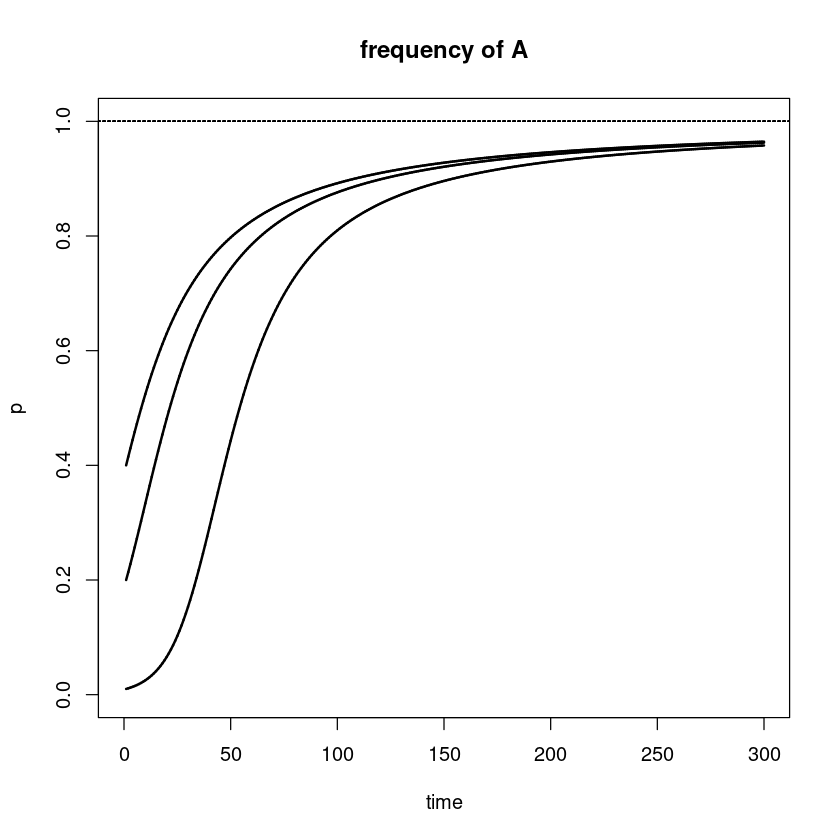

In [2]:
selection(p0 = 0.01, w = c(1, 1, 0.9), time = 300, pause = 0, show = 'p', equil = TRUE)
selection(p0 = 0.20, w = c(1, 1, 0.9), time = 300, pause = 0, show = 'p', add = TRUE)
selection(p0 = 0.40, w = c(1, 1, 0.9), time = 300, pause = 0, show = 'p', add = TRUE)

Comprueba que puedes utilizar la función `selection()` y entonces observa qué pasa en cada una de las situaciones descritas en la tabla siguiente. Observa que las distribuciones de eficacia biológica propuestas para cada modelo hacen que el alelo **A** (la frecuencia del cual es la representada) sea dominante en un caso, recesivo en otro, y parcialmente recesivo en el tercero. Asegúrate de utilizar diferentes valores de frecuencia inicial. 

 | Model                              | Eficàcia d'**AA** | Eficàcia d'**Aa** | Eficàcia d'**aa** |
 | ---------------------------------- |------------------:| -----------------:| -----------------:|
 | Selección a favor del dominante    |          1.0      |         1.0       |         0.9       |
 | Selección a favor del recesivo     |          1.0      |         0.8       |         0.8       |
 | Selección a favor del heterocigoto |          0.8      |         1.0       |         0.9       |

In [2]:
# Puedes introducir aquí los comandos que necesitas para ejecutarlos.
# Para copiar, selecciona y usa la combinación de teclas Ctrl+C.
# Para pegar, Ctrl+V
selection(p0 = , w = c( , , ), time = , pause = 0, show = 'p', equil = TRUE)



Contesta las preguntas siguientes.

### 1.1 ¿Cómo influye el tipo de herencia (recesiva o dominante) sobre la fijación de un alelo favorecido por la selección natural?

### 1.2 ¿Puedes explicar el patrón observado?

### 1.3 ¿Qué peculiaridad caracteriza la selección a favor del heterocigoto?

### 1.4 Los equilibrios alcanzados ¿son estables o inestables?

## Ejercicio 2. Deriva genética
Para estudiar el efecto de la deriva genética sobre una población de tamaño finito, utilizaremos la función `genetic.drift()`, que acepta los parámetros siguientes:

- `p0`: Frecuencia inicial del alelo **A** (0.5 por defecto)
- `Ne`: Tamaño poblacional efectivo (20 por defecto).
- `nrep`: Número de réplicas a simular (10 por defecto).
- `time`: Número de generaciones a simular.
- `show`: Opciones de representación gráfica:
   - `'p'`: la frecuencia del alelo **A** respecto al tiempo (por defecto).
   - `'fixedLast'`: proporción de poblaciones en las que al final se ha fijado un alelo u otro.
   - `'heterozygosity'`: la heterocigosidad observada y teórica respecto al tiempo.
   - `'genotypes'`: histograma *dinámico* (o secuencia de histogramas) de frecuencias genotípicas.
- `pause`: Tiempo (en segundos) de pausa entre generaciones, para suavizar las animaciones. Utiliza "0".

In [ ]:
sim02 <- genetic.drift(p0 = 0.5,
                       Ne = 20,
                       nrep = 10,
                       time = 100,
                       pause = 0)
plot(sim02, show = 'fixedLast')

El objetivo es determinar cómo afectan el tamaño poblacional (`Ne`) y la frecuencia inicial del alelo **A** (`p0`) a la proporción de casos en los que al final de la simulación se fije un alelo u otro. Utiliza el bloque de código a continuación para realizar todas las simulaciones necesarias para averiguarlo. Es recomendable simular siempre 100 réplicas (`nrep = 100`), durante 300 generaciones (`time = 300`) (también puedes probar otro número de generaciones como 30 o 100 para observar como afecta este parámetro), y combinar cuatro valores de `p0` (0.1, 0.2, 0.4 y 0.5), con al menos tres valores diferentes de `Ne` (10, 50 y 100). Si la simulación es demasiado lenta, reduce el número de generaciones y prueba solamente los valores de `Ne` inferiores a 100.

In [ ]:
# Puedes seleccionar el código anterior, copiarlo ("Ctrl+C"), pegarlo aquí,
# ("Ctrl+V"),modificarlo y ejecutarlo ("Shift+Enter").


Intenta contestar a las preguntas siguientes:

### 2.1 Si en una simulación haces 100 réplicas (`nrep = 100`), cada réplica representa una población. ¿Es posible predecir los cambios de frecuencia alélica en una población concreta?

### 2.2 Habrás observado que si se deja pasar suficiente tiempo en cualquier población únicamente queda uno de los dos alelos. ¿Qué factor influye más en el *tiempo* que tarda en desaparecer el polimorfismo?

### 2.3 ¿Qué efecto tiene la frecuencia alélica inicial, $p_0$?

### 2.4 Sabiendo que en última instancia se fijará un alelo u otro, ¿sabrías decir cuál es la probabilidad de que acabe fijándose cada alelo?

## Ejercicio 3. Selección y deriva

Cuando un locus polimórfico afecta la eficacia biológica en una población finita, los cambios en las frecuencias alélicas de ese locus están determinadas conjuntamente por la selección natural y por la deriva. Para simular poblaciones en las que actúan simultaneamente la selección natural y la deriva utilizaremos la función `drift.selection()`, que admite los parámetros siguientes:

- `p0`: frecuencia inicial del alelo **A**.
- `Ne`: tamaño poblacional efectivo.
- `w`: vector de eficacias biológicas de los genotipos **AA**, **Aa** i **aa**.
- `nrep`: Número de réplicas a simular.
- `ngen`: Número total de generaciones.

In [ ]:
sim03 <- drift.selection(p0 = 0.5,
                         Ne = 100,
                         w = c(0.96, 0.96, 1.0),
                         nrep = 30,
                         ngen = 300)

Para estudiar el efecto de la frecuencia inicial (`p0`), el tamaño poblacional (`Ne`) y el tipo de selección natural (`w`), tienes a contincuación tres plantillas, una para cada tipo de selección natural. Sobre cada plantilla, varía sistemáticamente la frecuencia inicial (valores sugeridos: 0.1, 0.2, 0.4 y 0.5) manteniendo el tamaño poblacional constante `Ne = 50` (por ejemplo). Despés, mantén constante la frecuencia inicial (`p0 = 0.2`, por ejemplo) y cambia el tamaño poblacional (10, 50 i 100, por ejemplo). Algunas simulaciones pueden ser lentas. Observa el círculo en la esquina superior derecha de la ventana: si está oscuro es que el *kernel* está trabajando y hay que esperar. Al acabar, contesta las preguntas siguientes:

In [ ]:
# Selección a favor del dominante
sim03.1 <- drift.selection(p0 = 0.1,
                           Ne = 50,
                           w  = c(1.0, 1.0, 0.9),
                           nrep = 30,
                           ngen = 300)

In [ ]:
# Selección a favor del recesivo
sim03.2 <- drift.selection(p0 = 0.1,
                           Ne = 50,
                           w  = c(1.0, 0.9, 0.9),
                           nrep = 30,
                           ngen = 300)

In [ ]:
# Selección a favor del heterocigoto
sim03.3 <- drift.selection(p0 = 0.1,
                           Ne = 50,
                           w  = c(0.8, 1.0, 0.9),
                           nrep = 30,
                           ngen = 300)

### 3.1 Cuando un alelo se acaba fijando, ¿puedes determinar si ha sido a causa de la deriva o de la selección natural?

### 3.2 Cuando aparece un alelo por mutación, su frecuencia es 1/2N si la población es diploide. Si este alelo es beneficioso, ¿en qué población crees que tendrá mayor probabilidad de llegar a fijarse, en una grande o en una pequeña? ¿Por qué?

### 3.3 La deriva dificulta la fijación del alelo beneficioso. ¿Lo hace de la misma manera cuando el alelo es recesivo que cuando es dominante?

### 3.4 La selección a favor del heterocigoto tiende a mantener el polimorfismo. En las poblaciones que has simulado, ¿crees que el polimorfismo puede mantenerse siempre? ¿Por qué? ¿Cómo lo comprobarías?

## Bibliografía
[1] Revell LJ (2019). *learnPopGen: Population Genetic Simulations & Numerical Analysis.* R package version 1.0.4, [https://CRAN.R-project.org/package=learnPopGen](https://CRAN.R-project.org/package=learnPopGen)